In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

#### Exercise 4.1

In [2]:
"""
Five one-sentence backtest descriptions, each containing exactly one hidden bias from this
catalog. Name each before reading the answers in Appendix A; they are the calibration test for
the whole section.
1. We tested a value strategy on the current constituents of the S&P; 500 back to 1995.
    Survivorship bias: looking at the samples of companies in the SP500 today ignores the ones that
    failed and were removed from the index. Hindsight view of companies that perform well.
2. The signal buys when GDP growth, from the standard downloadable series, crosses above 2 percent.
    Revision bias: the standard downloadable series contain revised GDP figures, not the one that
    was announced and known at the execution point-in-time.
3. Our universe is all stocks that maintained at least 5 dollars average price over the sample.
    Selection bias: using information that is only known at the end of the sample to determine 
    the selection criteria, not something that would be known at execution point-in-time.
4. The model trades each day at that day's close, using a signal computed from that day's close.
    Lookahead bias: entry is determined based on information that would not be available yet.
5. We assume our limit orders fill whenever the low of the bar touches our price.
    Fill bias: assuming your order would be filled where liquidity in the bar is thinnest and 
    queue order is likely unfavourable.
Each of these sentences has appeared, nearly verbatim, in published strategy write-ups. The skill
being trained is hearing the bias inside ordinary, confident, professional-sounding prose, because
that is the form in which you will meet it, including in your own.
"""

"\nFive one-sentence backtest descriptions, each containing exactly one hidden bias from this\ncatalog. Name each before reading the answers in Appendix A; they are the calibration test for\nthe whole section.\n1. We tested a value strategy on the current constituents of the S&P; 500 back to 1995.\n    Survivorship bias: looking at the samples of companies in the SP500 today ignores the ones that\n    failed and were removed from the index. Hindsight view of companies that perform well.\n2. The signal buys when GDP growth, from the standard downloadable series, crosses above 2 percent.\n    Revision bias: the standard downloadable series contain revised GDP figures, not the one that\n    was announced and known at the execution point-in-time.\n3. Our universe is all stocks that maintained at least 5 dollars average price over the sample.\n    Selection bias: using information that is only known at the end of the sample to determine \n    the selection criteria, not something that would

#### Exercise 5.1

In [3]:
# Read csv of unclean raw price; assume csv file is in the same folder as this notebook
dirty_prices_csv = 'period-2-dirty-prices.csv'
dirty_prices = pd.read_csv(dirty_prices_csv)

# Create copy, convert date format, and calc returns
df = dirty_prices.copy()
df['date'] = pd.to_datetime(df['date'])
df['return'] = df['close'].pct_change()
df['adj_close'] = df['close']

# Read csv of cross-reference price
clean_prices_csv = 'period-2-clean-reference.csv'
clean_prices = pd.read_csv(clean_prices_csv)
clean_prices['date'] = pd.to_datetime(clean_prices['date'])
clean_prices['return'] = clean_prices['close'].pct_change()

In [4]:
# Step 1a: identify the weekdays in the date range
weekdays = pd.bdate_range('2025-01-02', '2026-02-25')

# Expected number of trading days
print(len(weekdays))

# Actual number of unique trading dates
print(df['date'].nunique())

# Step 1b: find the missing date
missing_date = [i for i in weekdays if i not in df['date'].values]
print('missing date: ' + str(missing_date))
print('data on second source: ')
print(clean_prices[clean_prices['date'] == pd.to_datetime(missing_date[0])])

# Google search confirmed that, even though there was government shutdown on this date, US trading market was open. Unable to
# clarify further unless exact ticker/asset is known.

300
299
missing date: [Timestamp('2025-10-09 00:00:00')]
data on second source: 
          date  close    return
199 2025-10-09  63.29 -0.005187


<Axes: xlabel='date', ylabel='z_score'>

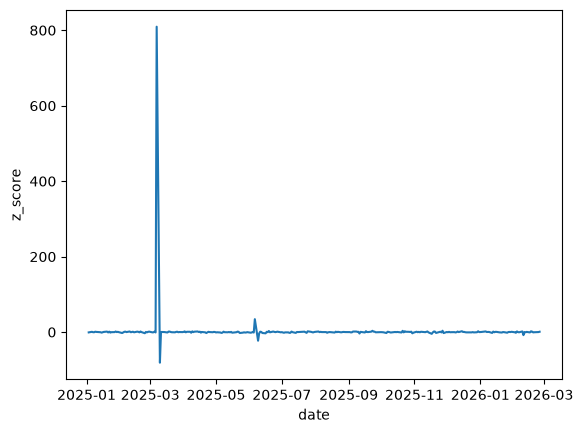

In [5]:
# Step 2a: calculate z-scores on returns using median and median abs dev
def calc_robust_zscore(ret):
    median = ret.median()
    abs_dev = np.abs(ret - median)
    median_abs_dev = abs_dev.median()
    z_score = 0.6745 * (ret - median) / median_abs_dev
    return z_score
df['z_score'] = calc_robust_zscore(df['return'])
clean_prices['z_score'] = calc_robust_zscore(clean_prices['return'])

# Step 2b: visually inspect z-score across sample
sns.lineplot(data=df, x='date', y='z_score')

In [6]:
# Step 2c: Two unusual spikes, find and view the dates
spike_date = df[df['z_score'].abs() > 8]['date'].values
df[df['date'].isin(spike_date)], clean_prices[clean_prices['date'].isin(spike_date)]

# mismatch on 2025-03-07, a 900% spike, seems to come from a decimal shift. Resolution is to accept second source data.
# data on 2025-06-06, a 38% spike, only appears in the first data source and not second. Resolution is to delete this row.
# return on 2026-02-10 is an unusual spike, but both sources confirm the same reading. Treated as a standard, volatile day

(          date   close  volume    return  adj_close     z_score
 46  2025-03-07  784.70  178301  8.993632     784.70  809.449329
 47  2025-03-10   77.15  120189 -0.901682      77.15  -81.104067
 111 2025-06-06   92.94  263500  0.379955      92.94   34.240095
 112 2025-06-09   69.34   80181 -0.253927      69.34  -22.807756
 287 2026-02-10   57.87  203033 -0.089951      57.87   -8.050327,
           date  close    return   z_score
 46  2025-03-07  78.47 -0.000637 -0.001339
 47  2025-03-10  77.15 -0.016822 -1.468628
 111 2025-06-09  69.34  0.029547  2.735066
 287 2026-02-10  57.87 -0.089951 -8.098383)

In [7]:
# Step 3a: check staleness - runs of repeated prices
# Create a group identifier every time the return changes (i.e., non-zero diff)
is_zero = df['return'] == 0
blocks = (~is_zero).cumsum()

# Cumulative count within each block of zeros
df['consecutive_zeros'] = is_zero.groupby(blocks).cumsum()
df[df['consecutive_zeros'] >= 1]

,date,close,volume,return,adj_close,z_score,consecutive_zeros
155,2025-08-07,63.37,0,0.0,63.37,0.045059,1
156,2025-08-08,63.37,0,0.0,63.37,0.045059,2
157,2025-08-11,63.37,0,0.0,63.37,0.045059,3
160,2025-08-14,61.73,229859,0.0,61.73,0.045059,1
186,2025-09-19,61.06,250508,0.0,61.06,0.045059,1


In [8]:
# Step 3b: store the dates where return is 0 and cross-check with other source
zero_ret_dates = df[df['consecutive_zeros'] >=1]['date'].values
clean_prices[clean_prices['date'].isin(zero_ret_dates)]

,date,close,return,z_score
154,2025-08-07,63.55,0.002840,0.313900
155,2025-08-08,62.59,-0.015106,-1.313105
156,2025-08-11,62.00,-0.009426,-0.798188
159,2025-08-14,61.73,0.000000,0.056390
185,2025-09-19,61.06,0.000000,0.056390


In [9]:
# Conclusion: 3 consecutive zero return dates [2025-08-07, 2025-08-08, 2025-08-11] from Thurs-Mon in first data source have 
# 0 volume whilst # second source have different return/close, indicating a data issue with the first data source. 
# Go with the second source.

<Axes: xlabel='volume', ylabel='Count'>

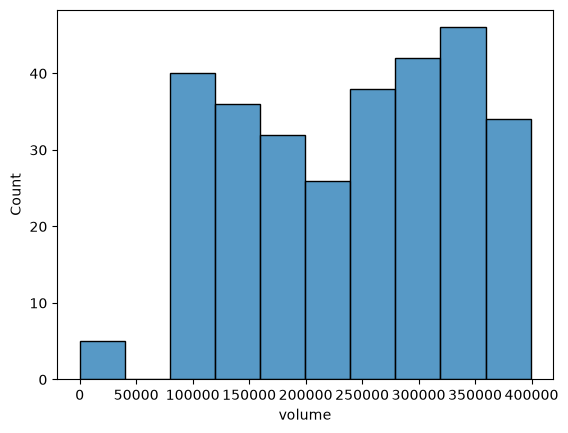

In [10]:
# Step 4a: given we found observations with 0 volume, check the distribution of volumes
sns.histplot(df, x='volume')

In [11]:
# Step 4b: check the dates where volume = 0 and compare between two sources
zero_volume_dates = df[df['volume'] == 0]['date'].values
print(df[df['date'].isin(zero_volume_dates)][['date', 'close', 'return']])
print(clean_prices[clean_prices['date'].isin(zero_volume_dates)][['date', 'close', 'return']])

          date  close    return
154 2025-08-06  63.37  0.006832
155 2025-08-07  63.37  0.000000
156 2025-08-08  63.37  0.000000
157 2025-08-11  63.37  0.000000
238 2025-12-03  63.15  0.006695
          date  close    return
153 2025-08-06  63.37  0.006832
154 2025-08-07  63.55  0.002840
155 2025-08-08  62.59 -0.015106
156 2025-08-11  62.00 -0.009426
238 2025-12-03  63.15  0.006695


In [12]:
# Aside from the dates with stale prices, other prices align between two sources. This indicates a server side recording issue.
# Conclusion from this is that analysis using volume need to account for these gaps. Because the second source does not contain
# volume data, either 1) forward fill the last volume (or average of x lookback volume) or 2) blackout volume analysis around these dates

In [13]:
# Step 5: apply adjustment and rationale
def log_adjustment(rationale_df, data_source, date, col_changed, prev_value, adj_value, decision, rationale):
    """
    Appends a new anomaly adjustment record to an audit trail DataFrame.
    """
    new_entry = {
        'data': data_source,
        'date': pd.to_datetime(date).strftime('%Y-%m-%d'),
        'col_changed': col_changed,
        'prev_value': prev_value,
        'adj_value': adj_value,
        'decision': decision,
        'rationale': rationale
    }
    
    # Initialize DataFrame with expected schema if None or empty
    if rationale_df is None or rationale_df.empty:
        return pd.DataFrame([new_entry])
    
    # Append new row using pd.concat for clean execution
    updated_df = pd.concat([rationale_df, pd.DataFrame([new_entry])], ignore_index=True)
    return updated_df
rationale_log = None
final_df = df.copy()
final_df['adj_flag'] = 0

# adjust and log
final_df.loc[final_df[final_df['date'] == pd.to_datetime('2025-03-07')].index, ['close', 'adj_flag']] = 78.47, 1
rationale_log = log_adjustment(
    rationale_df=rationale_log,
    data_source=dirty_prices_csv,
    date='2025-03-07',
    col_changed='close',
    prev_value=784.70,
    adj_value=78.47,
    decision='adjust',
    rationale='decimal shift print, 900% spike in return, z-score far past threshold'
)

final_df = final_df.drop(111)
rationale_log = log_adjustment(
    rationale_df=rationale_log,
    data_source=dirty_prices_csv,
    date='2025-06-06',
    col_changed='close',
    prev_value=92.94,
    adj_value=None,
    decision='delete',
    rationale='38% spike in return, date does not exist in second source'
)

for i in ['2025-08-07', '2025-08-08', '2025-08-11']:
    final_df.loc[final_df[final_df['date'] == pd.to_datetime(i)].index, 'adj_flag'] = 2
    rationale_log = log_adjustment(
        rationale_df=rationale_log,
        data_source=dirty_prices_csv,
        date=i,
        col_changed='close',
        prev_value=63.37,
        adj_value=None,
        decision='none',
        rationale='stale price, 0 volume, consecutive same price close for 4 days, flagged as untrusted'
    )

rationale_log = log_adjustment(
    rationale_df=rationale_log,
    data_source=dirty_prices_csv,
    date='2025-10-09',
    col_changed=None,
    prev_value=None,
    adj_value=None,
    decision='none',
    rationale='unexplained missing business day with no holiday'
)

for i in ['2025-08-06', '2025-12-03']:
    final_df.loc[final_df[final_df['date'] == pd.to_datetime(i)].index, 'adj_flag'] = 2
    rationale_log = log_adjustment(
        rationale_df=rationale_log,
        data_source=dirty_prices_csv,
        date=i,
        col_changed=None,
        prev_value=None,
        adj_value=None,
        decision='none',
        rationale='days with 0 volume, price is consistent with second source but flagged as untrusted'
    )

In [14]:
rationale_log.to_csv('price_adjustment_log.csv')
rationale_log

,data,date,col_changed,prev_value,adj_value,decision,rationale
0,period-2-dirty-prices.csv,2025-03-07,close,784.7,78.47,adjust,"decimal shift print, 900% spike in return, z-s..."
1,period-2-dirty-prices.csv,2025-06-06,close,92.94,None,delete,"38% spike in return, date does not exist in se..."
2,period-2-dirty-prices.csv,2025-08-07,close,63.37,None,none,"stale price, 0 volume, consecutive same price ..."
3,period-2-dirty-prices.csv,2025-08-08,close,63.37,None,none,"stale price, 0 volume, consecutive same price ..."
4,period-2-dirty-prices.csv,2025-08-11,close,63.37,None,none,"stale price, 0 volume, consecutive same price ..."
5,period-2-dirty-prices.csv,2025-10-09,None,None,None,none,unexplained missing business day with no holiday
6,period-2-dirty-prices.csv,2025-08-06,None,None,None,none,"days with 0 volume, price is consistent with s..."
7,period-2-dirty-prices.csv,2025-12-03,None,None,None,none,"days with 0 volume, price is consistent with s..."
